This is the reimplementation of the tutorial by Martin Uhrin and Thomas Hardin. Original links: 

[collab](https://colab.research.google.com/drive/1duR1Y-roE_CSL3hrGxINMZ4XIepHvoHt) 
[video](https://cwww.youtube.com/watch?v=6W3syIWfOA4)


In [ ]:

import ase
from ase import build
from e3nn_mlx import o3

import matplotlib.pyplot as plt
import numpy as np

import mlx.core as mx
from tensor_helpers import SphericalTensor

np.set_printoptions(precision=2)

In [2]:
# Some common functions I want to use
from other_helpers import view, show_array, plot, s2_grid, plot_sphere


In [3]:

# cmap_bwr = [[0, 'rgb(0,50,255)'], [0.5, 'rgb(200,200,200)'], [1, 'rgb(255,50,0)']]



# Analysing Geometry and Structure of Atomic Configurations with Equivariant and Invariant Functions

Martin Uhrin and Thomas Hardin - November, 29$^\text{th}$, 2021


# Motivation


Properties we would like $\Phi$ to have:
* Permutational invariance
* Translational invariance
* Rotational invariance
* Smoothness
* Completeness

In [4]:
molecule = build.molecule('CH3COCH3')
view(molecule)

In [5]:
show_array(molecule.positions)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': '3d60f657-c25f-4837-b78f-3466474571e5',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'ALsmU59L9ngAuyZTn0v2eAC7JlOfS/'),
                    'dtype': 'f8',
                    'shape': '3, 10'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                  

### 1. Permutation

In [6]:
def sum_coords(pos):
    # Sum the coordinates along x, y and z
    return pos.sum(axis=0).reshape(3, 1)

show_array(molecule.positions, sum_coords)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': 'bf653e71-197b-4aa9-8598-3724e2893844',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': 'AAAAAAAAAAAAAAAAAAAAAA0a+ie4SBLA', 'dtype': 'f8', 'shape': '1, 3'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                                            'rgb(247,247,247)'], [0.6,
                         

### 2. Translation

In [7]:
def center(pos):
    # Subtract centre of mass
    return (pos - pos.sum(axis=0) / len(pos))

show_array(molecule.positions, center)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': 'a0cd0057-c6e8-4d27-a0de-8ead95d2cbec',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'XoEDjS6b+QhegQONLpv5CF6BA40um/'),
                    'dtype': 'f8',
                    'shape': '3, 10'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                  

### 3. Rotation

In [8]:
def norms(pos):
    # Get norms of pos vectors
    return (pos**2).sum(axis=1).reshape(-1, 1)

show_array(molecule.positions, norms)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': '1be08393-25f8-4e73-9e5e-cc00c50abd73',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('dGY8/Gic/z+UJ/tsfmqgP72fQQJHQg' ... 'pIl5YQQKYn2kiXlhBApifaSJeWEEA='),
                    'dtype': 'f8',
                    'shape': '1, 10'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                  

Putting it all together

In [9]:
def invariance(pos):
    trans = center(pos)
    rots = norms(trans)
    return rots.sum().reshape(-1, 1)

show_array(molecule.positions, invariance)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': 'a02ec21d-fc3f-4f1e-b5ee-2da39a6c4f93',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': 'iDXDNyayPUA=', 'dtype': 'f8', 'shape': '1, 1'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                                            'rgb(247,247,247)'], [0.6,
                                            '

## Expanding a density in a spherical harmonic basis

The spherical harmonics are a basis for functions defined on the sphere.
For a given function on the sphere, $f$, we can find the expansions coefficients from

$c_{l}^m = \int_0^{2\pi} \int_0^\pi Y_l^m (\theta, \varphi) f(\theta, \varphi) \sin{\theta} d\theta d\varphi \text{,}$

and thanks to the orthonormality of spherical harmonics we can reconstruct (an approximation to) the function using

$\tilde{f}(\theta, \phi) = \sum_l \sum_{m = -l}^l c_{nl}^m Y_l^m(\theta, \phi)$

In [10]:
# Create a grid of points on the sphere
r = s2_grid()
plot_sphere(r)

In [11]:
# Plot x, y, z componenets separately
plot(r, radial_abs=False)

We can deform the spheres into a shape that has its radius equal to the absolute value of the plotted quantity:

In [12]:
plot(r)

These are the $l = 1$ spherical harmonics ($Y^1$).  Now, let's compute $Y^2$.

In [13]:
tp = o3.ElementwiseTensorProduct("1o", "1o", ['2e'], irrep_normalization='norm')
y2 = tp(r, r)
plot(y2)

And finally, let's do $Y^3$

In [14]:
tp = o3.ElementwiseTensorProduct("2e", "1o", ['3o'], irrep_normalization='norm')
y3 = tp(y2, r)
plot(y3)

So, let's expand our molecule in this basis

In [15]:
def calc_tensor(pos, values):
    sph_tensor = SphericalTensor(lmax=4, p_val=1, p_arg=-1).sum_of_diracs(
        mx.array(pos), mx.array(values))
    return sph_tensor.reshape(-1, 5)

show_array(molecule.positions, lambda pos: calc_tensor(pos, molecule.numbers))

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': '6a11c7ca-93cb-4670-9b23-f604672278e1',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('DjORQAAAAAAAAAAAmqV/QMPBXUAAAA' ... 'MAAAAAAAAAAP2tgDIAAAAAlx2HQA=='),
                    'dtype': 'f4',
                    'shape': '5, 5'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                   

OK, but how to I get rotation invariants from this?

Let's look at the way our spherical tensor transforms as we form rotations:

In [16]:
def calc_rot_mtx(pos):
    pos = mx.array(pos)
    x = mx.array([1., 0, 0]); y = mx.array([0, 1., 0]);  z = mx.array([0., 0, 1.])
    irreps = SphericalTensor(5, 1, -1)
    # Calculate Wigner-D from Euler angles
    D = irreps.D_from_angles(mx.matmul(pos[0], x), mx.matmul(pos[0], y), mx.matmul(pos[0], z))
    return 3 * np.asarray(D)

show_array(molecule.positions, calc_rot_mtx)

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': 'd5318a3d-41ea-4698-9c9e-f4ed3a5682b2',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AABAQAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAADPKg1A'),
                    'dtype': 'f4',
                    'shape': '36, 36'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                 

#### Invariants from tensor products of irreducible representations

So we have found _one_ of our rotation invariants, but clearly this is an incomplete description of our function.

No problem - we can generate more invariants!


##### Degree-1 invariants

$c_{0}^0$ are invariants corresponding to $\mathbf{D}^0$.

#### Degree-2 invariants (power spectrum)

Invariants from a single tensor product $(\mathbf{D}^{l} \otimes \mathbf{D}^{l})^0$.

#### Degree-3 invariants (bispectrum)

Invariants from two tensor products $((\mathbf{D}^{l_1} \otimes \mathbf{D}^{l_2})^l \otimes \mathbf{D}^l)^0$.

#### Degree-4 invariants (trispectrum)

Invariants from three tensor products $((\mathbf{D}^{l_1} \otimes \mathbf{D}^{l_2})^l \otimes (\mathbf{D}^{l_3} \otimes \mathbf{D}^{l_4})^l)^0$

One can continue this up to arbitrary degree but, thus far, degree-4 has always been found to be sufficient to distinguish atomic configurations.

Let's use e3nn to calculate the bispectrum.

In [17]:
lmax = 4
bispectrum_main = o3.ReducedTensorProducts(
    'ijk=jik=ikj', i=o3.Irreps.spherical_harmonics(lmax),
    filter_ir_mid=list(o3.Irrep.iterator(lmax)), filter_ir_out=list(o3.Irrep.iterator(lmax=0)))
print(bispectrum_main.irreps_out)
bispectrum = lambda x : bispectrum_main(x, x, x)

0o+14x0e


In [18]:
def calc_bispectrum(pos, values):
    sph_tensor = SphericalTensor(lmax=lmax, p_val=1, p_arg=-1).sum_of_diracs(
        mx.array(pos), mx.array(values))
    return bispectrum(sph_tensor).reshape(-1, 1)

show_array(molecule.positions, lambda pos: calc_bispectrum(pos, molecule.numbers))

interactive(children=(FloatSlider(value=0.0, description='xrot', max=360.0, step=1.0), FloatSlider(value=0.0, …

FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': '764ac8d6-f89c-482d-9ff8-cb9513ae4f52',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': 'AAAAAJmhCsJqxH7D1+m1Qe0akUIJ5DJBaF6dQhSVyEFQ29Q/JTtsQtyhjEK72qjA4GlZwJbXukI6xgbB',
                    'dtype': 'f4',
                    'shape': '1, 15'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'cmax': 5,
                             'cmin': -5,
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
       

## What do the invariants tell us?

In [19]:
tetra = np.array([
    [0., 0., 0.],
    [1., 0., 1.],
    [0., 1., 1.],
    [1., 1., 0.]
])
tetra = tetra - tetra.mean(0, keepdims=True)
tetra /= np.linalg.norm(tetra, keepdims=True, axis=-1)
view(ase.Atoms(positions=tetra))

In [20]:
def tetra_to_seesaw(t):
    upper_scale = (1 - t) / 1
    lower_scale = 1 / (1 - t)
    return np.array([
        [-0.57735027 * lower_scale, -0.57735027 * lower_scale, -0.57735027],
        [ 0.57735027 * lower_scale,  0.57735027 * lower_scale, -0.57735027],
        [ 0.57735027 * upper_scale, -0.57735027 * upper_scale,  0.57735027],
        [-0.57735027 * upper_scale,  0.57735027 * upper_scale,  0.57735027],])

seesaw = tetra_to_seesaw(0.5)
view(ase.Atoms(positions=seesaw))

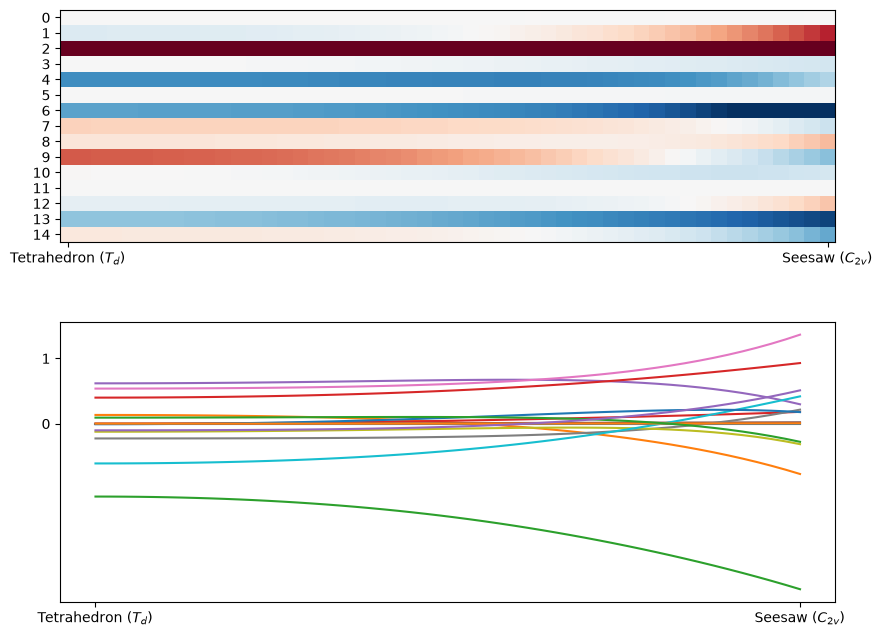

In [21]:
scale = 1.5
tetra_seesaw = [tetra_to_seesaw(i) * scale  for i in np.linspace(0, 0.5, 50)]

bis = []

for shape in tetra_seesaw:
    bis.append(
        bispectrum(
            SphericalTensor(lmax, p_val=1, p_arg=-1).with_peaks_at(
                mx.array(shape))
        )
    )

bis = mx.stack((bis), axis=0)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plt.sca(ax[0])
plt.yticks(list(range(15)))
plt.xticks([0, 49], ['Tetrahedron ($T_d$)', 'Seesaw ($C_{2v}$)'])
plt.imshow(bis.T, cmap='RdBu', vmin=-1, vmax=1)
plt.sca(ax[1])
plt.yticks(list(range(15)))
plt.xticks([0, 49], ['Tetrahedron ($T_d$)', 'Seesaw ($C_{2v}$)'])
plt.plot(bis);